In [1]:
import numpy as np
import matplotlib.pyplot as plt
import csv
from algorithms import globals
import os
import numpy as np

num_of_thresholds = 10000



In [2]:
def scale(x):
    a, b = globals.def_clamps
    c, d = globals.original_clamps

    x_scaled = ((x - a) / (b - a)) * (d - c) + c
    return x_scaled



In [3]:
# logs = [
# # ADAM 0 - 10 (test all versions with the same parameters : 0.01 B1=0.9 B2=0.999)
#     { "name" : "adam clamp lr=0.01 B1=0.8 B2=0.99", "path": "./.archive/Adam/adam_clamp_lr=0.01_B1=0.8_B2=0.99_logs/adam_clamp_lr=0.01_B1=0.8_B2=0.99_records_", "run_path": "./.archive/Adam/adam_clamp_lr=0.01_B1=0.8_B2=0.99_logs/adam_clamp_lr=0.01_B1=0.8_B2=0.99_run_records_"},
#     { "name" : "adam clamp lr=0.001 B1=0.8 B2=0.99", "path": "./.archive/Adam/adam_clamp_lr=0.001_B1=0.8_B2=0.99_logs/adam_clamp_lr=0.001_B1=0.8_B2=0.99_records_", "run_path": "./.archive/Adam/adam_clamp_lr=0.001_B1=0.8_B2=0.99_logs/adam_clamp_lr=0.001_B1=0.8_B2=0.99_run_records_"},
#     { "name" : "adam clamp lr=0.001 B1=0.9 B2=0.999", "path": "./.archive/Adam/adam_clamp_lr=0.001_B1=0.9_B2=0.999_logs/adam_clamp_lr=0.001_B1=0.9_B2=0.999_records_", "run_path": "./.archive/Adam/adam_clamp_lr=0.001_B1=0.9_B2=0.999_logs/adam_clamp_lr=0.001_B1=0.9_B2=0.999_run_records_"},
#     { "name" : "adam clamp lr=0.01 B1=0.9 B2=0.999", "path": "./.archive/Adam/adam_clamp_lr=0.01_B1=0.9_B2=0.999_logs/adam_clamp_lr=0.01_B1=0.9_B2=0.999_records_", "run_path": "./.archive/Adam/adam_clamp_lr=0.01_B1=0.9_B2=0.999_logs/adam_clamp_lr=0.01_B1=0.9_B2=0.999_run_records_"},
   
#     { "name" : "adam clamp lr=0.01 B1=0.9 B2=0.999_t2", "path": "./.archive/Adam/adam_clamp_lr=0.01_B1=0.9_B2=0.999_t2_logs/adam_clamp_lr=0.01_B1=0.9_B2=0.999_t2_records_", "run_path": "./.archive/Adam/adam_clamp_lr=0.01_B1=0.9_B2=0.999_t2_logs/adam_clamp_lr=0.01_B1=0.9_B2=0.999_t2_run_records_"},

#     { "name" : "Adam grad div norm lr=0.01 B1=0.9 B2=0.999", "path": "./.archive/Adam/adam_norm_graddiv_lr=0.01_B1=0.9_B2=0.999_logs/adam_norm_graddiv_lr=0.01_B1=0.9_B2=0.999_records_", "run_path": "./.archive/Adam/adam_norm_graddiv_lr=0.01_B1=0.9_B2=0.999_logs/adam_norm_graddiv_lr=0.01_B1=0.9_B2=0.999_run_records_"},
   
#     { "name" : "Adam lr=0.01 B1=0.9 B2=0.999", "path": "./.archive/Adam/adam_logs_lr=0.01/adam_records_", "run_path": "./.archive/Adam/adam_logs_lr=0.01/adam_run_records_"},
    
#     { "name" : "Adam norm lr=0.01 B1=0.9 B2=0.999", "path": "./.archive/Adam/adam_logs_norm_lr=0.01/adam_records_", "run_path": "./.archive/Adam/adam_logs_norm_lr=0.01/adam_run_records_"},
#     { "name" : "Adam norm lr=0.001 B1=0.8 B2=0.99", "path": "./.archive/Adam/adam_logs_norm_lr=0.001_B1=0.8_B2=0.99/adam_records_", "run_path": "./.archive/Adam/adam_logs_norm_lr=0.001_B1=0.8_B2=0.99/adam_run_records_"},
#     { "name" : "Adam norm lr=0.01 B1=0.8 B2=0.99", "path": "./.archive/Adam/adam_logs_norm_lr=0.01_B1=0.8_B2=0.99/adam_records_", "run_path": "./.archive/Adam/adam_logs_norm_lr=0.01_B1=0.8_B2=0.99/adam_run_records_"},
#     { "name" : "Adam norm lr=0.001 B1=0.9 B2=0.999", "path": "./.archive/Adam/adam_logs_norm_lr=0.001/adam_records_", "run_path": "./.archive/Adam/adam_logs_norm_lr=0.001/adam_run_records_"},

# # CMAES 12 - 14
#     { "name" : "CMAES", "path": "./.archive/CMAES/cmaes_logs/cmaes_records_", "run_path": "./.archive/CMAES/cmaes_logs/cmaes_run_records_"},
    
#     { "name" : "cmaes clamp", "path": "./.archive/CMAES/cmaes_clamp_logs/cmaes_clamp_records_", "run_path": "./.archive/CMAES/cmaes_clamp_logs/cmaes_clamp_run_records_"},
#     { "name" : "cmaes clamp lambd=4m", "path": "./.archive/CMAES/cmaes_clamp_lambd=4m_logs/cmaes_clamp_lambd=4m_records_", "run_path": "./.archive/CMAES/cmaes_clamp_lambd=4m_logs/cmaes_clamp_lambd=4m_run_records_"},   
   

# # ADAGRAD 15 - 21
#     { "name" : "adagrad lr=0.01", "path": "./.archive/Adagrad/adagrad_lr=0.01_logs/adagrad_records_", "run_path": "./.archive/Adagrad/adagrad_lr=0.01_logs/adagrad_run_records_"},

#     { "name" : "adagrad clamp lr=0.1", "path": "./.archive/Adagrad/adagrad_clamp_lr=0.1_logs/adagrad_clamp_lr=0.1_records_", "run_path": "./.archive/Adagrad/adagrad_clamp_lr=0.1_logs/adagrad_clamp_lr=0.1_run_records_"},
#     { "name" : "adagrad clamp lr=0.01", "path": "./.archive/Adagrad/adagrad_clamp_lr=0.01_logs/adagrad_clamp_lr=0.01_records_", "run_path": "./.archive/Adagrad/adagrad_clamp_lr=0.01_logs/adagrad_clamp_lr=0.01_run_records_"},
#     { "name" : "adagrad clamp lr=0.001", "path": "./.archive/Adagrad/adagrad_clamp_lr=0.001_logs/adagrad_clamp_lr=0.001_records_", "run_path": "./.archive/Adagrad/adagrad_clamp_lr=0.001_logs/adagrad_clamp_lr=0.001_run_records_"},
#     { "name" : "adagrad clamp lr=0.1 rho=0.1", "path": "./.archive/Adagrad/adagrad_clamp_lr=0.1_rho=0.1_logs/adagrad_clamp_lr=0.1_rho=0.1_records_", "run_path": "./.archive/Adagrad/adagrad_clamp_lr=0.1_rho=0.1_logs/adagrad_clamp_lr=0.1_rho=0.1_run_records_"},
#     { "name" : "adagrad clamp lr=1.0 rho=0.1", "path": "./.archive/Adagrad/adagrad_clamp_lr=1.0_rho=0.1_logs/adagrad_clamp_lr=1.0_rho=0.1_records_", "run_path": "./.archive/Adagrad/adagrad_clamp_lr=1.0_rho=0.1_logs/adagrad_clamp_lr=1.0_rho=0.1_run_records_"},
#     { "name" : "adagrad clamp lr=1.0", "path": "./.archive/Adagrad/adagrad_clamp_lr=1.0_logs/adagrad_clamp_lr=1.0_records_", "run_path": "./.archive/Adagrad/adagrad_clamp_lr=1.0_logs/adagrad_clamp_lr=1.0_run_records_"},

# #BFGS 22 - 23
#     { "name" : "BFGS clamp def", "path": "./.archive/BFGS/BFGS_clamp_def_logs/BFGS_clamp_def_records_", "run_path": "./.archive/BFGS/BFGS_clamp_def_logs/BFGS_clamp_def_run_records_"},
#     { "name" : "BFGS clamp penalty", "path": "./.archive/BFGS/BFGS_clamp_penalty_logs/BFGS_clamp_penalty_records_", "run_path": "./.archive/BFGS/BFGS_clamp_penalty_logs/BFGS_clamp_penalty_run_records_"},
#     { "name" : "L-BFGS-B clamp", "path": "./.archive/BFGS/L_BFGS_B_clamp_logs/L_BFGS_B_clamp_records_", "run_path": "./.archive/BFGS/L_BFGS_B_clamp_logs/L_BFGS_B_clamp_run_records_"},
# #mbien 24 
#     { "name" : "mbien cmaes", "path": "./.archive/mbien_cmaes/mbien_cmaes_logs/mbien_cmaes_records_", "run_path": "./.archive/mbien_cmaes/mbien_cmaes_logs/mbien_cmaes_run_records_"},

# ]

In [4]:
logs = [
    { "name" : "cmaes", "path": "./networks/cmaes_net_logs/cmaes_net_records.csv", "run_path": "./networks/cmaes_net_logs/cmaes_net_run_records.csv"},
    { "name" : "adam", "path": "./networks/adam_net_logs/adam_net_records.csv", "run_path": "./networks/adam_net_logs/adam_net_run_records.csv"},
]

In [5]:
def get_records(path):

    if not os.path.exists(path):
        records = None
    else:
        records = []
        with open(path, mode='r', newline='') as file:
            reader = csv.DictReader(file)
            for row in reader:
                converted_row = {
                    key: (float(value.strip('[]')) if key != 'algorithm' else value)
                    for key, value in row.items()
                }
                records.append(converted_row)

    return records


In [6]:

def calculate_thresholds(algs_run_records):

    all_errors = [
        r['error']
        for records in algs_run_records.values()
        for r in records
    ]

    all_errors = np.array(all_errors)
    all_errors = all_errors[all_errors >= globals.def_smallest_val]

    percentiles = np.linspace(0, 100, num=num_of_thresholds + 1)
    thresholds = np.percentile(all_errors, percentiles)


    # min_error = np.min(all_errors)
    # max_error = np.max(all_errors)

    # min_error = max(min_error, globals.def_smallest_val)

    # thresholds = np.linspace(min_error, max_error, num=num_of_thresholds + 1)

    return thresholds

In [7]:
def ecdf(run_records, thresholds):
    checkpoint_run_errors = {}

    for r in run_records:
        chk = r['checkpoint']
        error = (1-r['error'])
            
        if chk not in checkpoint_run_errors:
            checkpoint_run_errors[chk] = []
        checkpoint_run_errors[chk].append(error)

    avg_part_of_thresholds_reached = []
    prev_reached = None

    for chk in globals.def_checkpoints:
        errors = checkpoint_run_errors.get(chk, [])
        if not errors:
            if prev_reached is None:
                avg_part_of_thresholds_reached.append(0)
            else:
                avg_part_of_thresholds_reached.append(np.mean(prev_reached))
            continue

        fractions = []
        for e in errors:
            reached_now = e <= thresholds

            if prev_reached is not None:
                reached_now = np.maximum(prev_reached, reached_now)

            fractions.append(np.sum(reached_now) / len(thresholds))

        avg_fraction = np.mean(fractions)
        avg_part_of_thresholds_reached.append(avg_fraction)

        combined_reached = np.zeros(len(thresholds), dtype=bool)
        for e in errors:
            combined_reached = np.maximum(combined_reached, e <= thresholds)

        if prev_reached is None:
            prev_reached = combined_reached
        else:
            prev_reached = np.maximum(prev_reached, combined_reached)

    return avg_part_of_thresholds_reached



In [8]:
def compare(logs):
    checkpoints = globals.def_checkpoints

    algs_run_records = {}
    algs_records = {}

    for algorithm in logs:
        algs_records[algorithm['name']] = get_records(f"{algorithm['path']}")
        algs_run_records[algorithm['name']] = get_records(f"{algorithm['run_path']}")

    fig, axs = plt.subplots(1, 2, figsize=(20, 8))
    axs = axs.flatten()
    plot_idx = 0

    # ECDF
    ecdf_thresholds = calculate_thresholds(algs_run_records)

    ax = axs[plot_idx]
    for algorithm_name, run_record in algs_run_records.items():
        y = ecdf(run_record, ecdf_thresholds)
        ax.plot(globals.def_checkpoints, y, label=algorithm_name, marker='o')

    ax.set_xlabel('Checkpoint (evaluations)')
    ax.set_ylabel('Fraction of thresholds reached (ECDF)')
    ax.set_title(f"learning method comparison, ECDF")
    ax.set_xscale('log')
    ax.set_ylim([0, 1.05])
    ax.grid(True)
    ax.legend()

    plot_idx += 1

    # Mean + Std
    ax = axs[plot_idx]
    for algorithm_name, records in algs_records.items():
        means = []
        stds = []

        for checkpoint in checkpoints:
            if records:
                mean_vals = [r['mean'] for r in records if r['checkpoint'] == checkpoint]
                std_vals = [r['std'] for r in records if r['checkpoint'] == checkpoint]
                means.append(np.mean(mean_vals) if mean_vals else 0)
                stds.append(np.mean(std_vals) if std_vals else 0)
            else:
                means.append(0)
                stds.append(0)

        ax.plot(checkpoints, means, label=algorithm_name, marker='o')
        ax.fill_between(checkpoints,
                        np.array(means) - np.array(stds),
                        np.array(means) + np.array(stds),
                        alpha=0.2)

    ax.set_xlabel('Checkpoint')
    ax.set_ylabel("Accuracy")
    ax.set_title(f"learning method comparison, mean and std")
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.legend()
    ax.grid(True)

    plot_idx += 1

    plt.tight_layout()
    # plt.savefig(f"./charts/net/1.png", transparent=False, facecolor='white', dpi=300)

    plt.show()


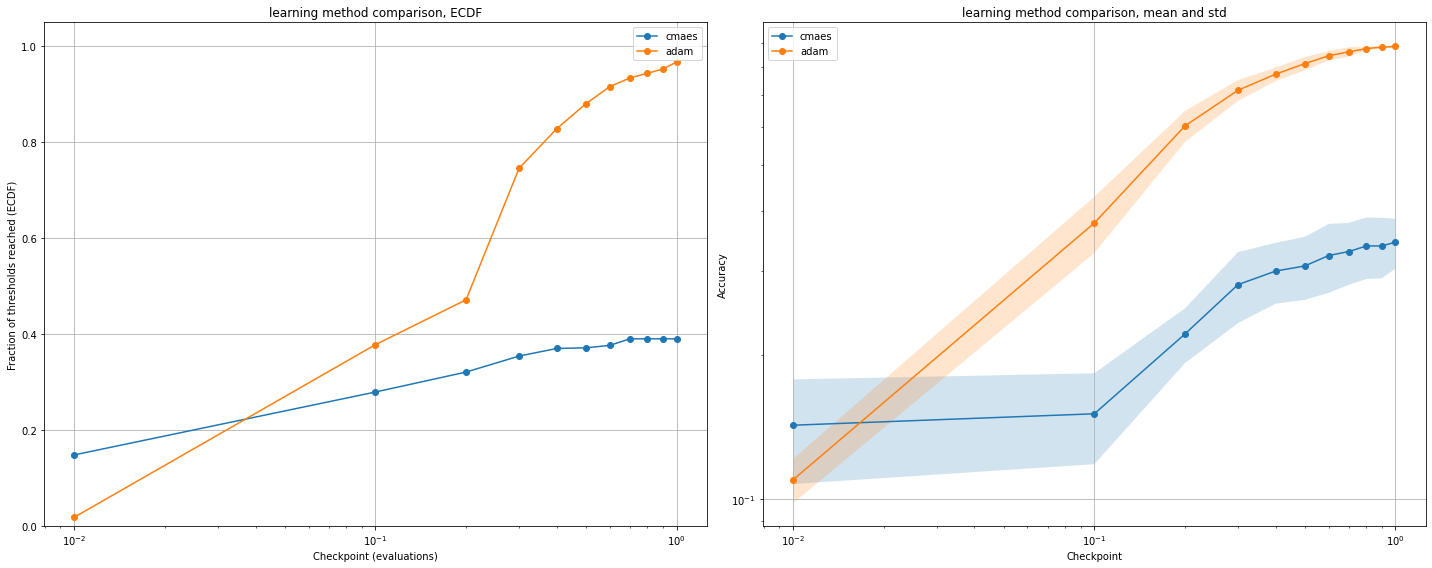

In [9]:
to_compare = []

# indxs = [3, 4, 5, 6, ]
# indxs = [10, 11, 12]
indxs = [0, 1]

for i in indxs:
    to_compare.append(logs[i])

compare(to_compare)

In [10]:
data = """F22013,30,0,0.01,[673821.6065998548]
F22013,30,0,0.1,[597.4945295130403]
F22013,30,0,0.2,[39.84433133699963]
F22013,30,0,0.3,[0.4361498323255546]
F22013,30,0,0.4,[0.0064392074680199585]
F22013,30,0,0.5,[0.00015364944260909397]
F22013,30,0,0.6,[7.921501855889801e-05]
F22013,30,0,0.7,[7.921501855889801e-05]
F22013,30,0,0.8,[7.921501855889801e-05]
F22013,30,0,0.9,[7.921501855889801e-05]
F22013,30,0,1.0,[7.921501855889801e-05]
F22013,30,1,0.01,[549429.1620131462]
F22013,30,1,0.1,[278.1809537458072]
F22013,30,1,0.2,[5.796574675586726]
F22013,30,1,0.3,[0.11928352552331489]
F22013,30,1,0.4,[0.0032370879605423397]
F22013,30,1,0.5,[8.683983696755604e-05]
F22013,30,1,0.6,[1.1681714340738836e-05]
F22013,30,1,0.7,[1.1681714340738836e-05]
F22013,30,1,0.8,[1.1681714340738836e-05]
F22013,30,1,0.9,[1.1681714340738836e-05]
F22013,30,1,1.0,[1.1681714340738836e-05]
F22013,30,2,0.01,[475739.7964695703]
F22013,30,2,0.1,[928.5283329031885]
F22013,30,2,0.2,[18.873101364164086]
F22013,30,2,0.3,[0.006950241228196319]
F22013,30,2,0.4,[0.00014270727251641802]
F22013,30,2,0.5,[0.00014270727251641802]
F22013,30,2,0.6,[0.00014270727251641802]
F22013,30,2,0.7,[0.00014270727251641802]
F22013,30,2,0.8,[0.00014270727251641802]
F22013,30,2,0.9,[0.00014270727251641802]
F22013,30,2,1.0,[0.00014270727251641802]
F22013,30,3,0.01,[442640.6904487404]
F22013,30,3,0.1,[822.1709976694157]
F22013,30,3,0.2,[37.8400643471889]
F22013,30,3,0.3,[4.931424703210723]
F22013,30,3,0.4,[0.05104796301748138]
F22013,30,3,0.5,[0.0007466002321052656]
F22013,30,3,0.6,[0.00010114546489603526]
F22013,30,3,0.7,[0.00010114546489603526]
F22013,30,3,0.8,[0.00010114546489603526]
F22013,30,3,0.9,[0.00010114546489603526]
F22013,30,3,1.0,[0.00010114546489603526]
F22013,30,4,0.01,[374225.6272272405]
F22013,30,4,0.1,[3652.31818966171]
F22013,30,4,0.2,[63.447983905803994]
F22013,30,4,0.3,[4.071272260422347]
F22013,30,4,0.4,[0.012297147432491329]
F22013,30,4,0.5,[0.0014253360463953868]
F22013,30,4,0.6,[0.0001274876931347535]
F22013,30,4,0.7,[2.5348889948872966e-05]
F22013,30,4,0.8,[2.5348889948872966e-05]
F22013,30,4,0.9,[2.5348889948872966e-05]
F22013,30,4,1.0,[2.5348889948872966e-05]
F22013,30,5,0.01,[436963.2856933982]
F22013,30,5,0.1,[422.9662767213156]
F22013,30,5,0.2,[6.0742615428423505]
F22013,30,5,0.3,[0.530028446368533]
F22013,30,5,0.4,[0.05530849519300318]
F22013,30,5,0.5,[0.002856870133200573]
F22013,30,5,0.6,[0.0001699191820989654]
F22013,30,5,0.7,[2.338742228857882e-05]
F22013,30,5,0.8,[2.338742228857882e-05]
F22013,30,5,0.9,[2.338742228857882e-05]
F22013,30,5,1.0,[2.338742228857882e-05]
F22013,30,6,0.01,[556697.1154652936]
F22013,30,6,0.1,[1454.8158928788096]
F22013,30,6,0.2,[36.56612587521249]
F22013,30,6,0.3,[2.098297491782205]
F22013,30,6,0.4,[0.4753369756538177]
F22013,30,6,0.5,[0.015460890117765302]
F22013,30,6,0.6,[0.0001981390255423321]
F22013,30,6,0.7,[0.0001266897982077353]
F22013,30,6,0.8,[0.0001266897982077353]
F22013,30,6,0.9,[0.0001266897982077353]
F22013,30,6,1.0,[0.0001266897982077353]
F22013,30,7,0.01,[412994.3443688493]
F22013,30,7,0.1,[399.0669222245822]
F22013,30,7,0.2,[4.893289694036866]
F22013,30,7,0.3,[0.06861111092871397]
F22013,30,7,0.4,[0.0034851381205953658]
F22013,30,7,0.5,[3.755081365852675e-05]
F22013,30,7,0.6,[1.324324853158032e-05]
F22013,30,7,0.7,[1.324324853158032e-05]
F22013,30,7,0.8,[1.324324853158032e-05]
F22013,30,7,0.9,[1.324324853158032e-05]
F22013,30,7,1.0,[1.324324853158032e-05]
F22013,30,8,0.01,[845392.6450412497]
F22013,30,8,0.1,[764.7285923044639]
F22013,30,8,0.2,[8.29134852455877]
F22013,30,8,0.3,[0.4585968894875805]
F22013,30,8,0.4,[0.00772555278172149]
F22013,30,8,0.5,[8.142024626067723e-05]
F22013,30,8,0.6,[8.142024626067723e-05]
F22013,30,8,0.7,[8.142024626067723e-05]
F22013,30,8,0.8,[8.142024626067723e-05]
F22013,30,8,0.9,[8.142024626067723e-05]
F22013,30,8,1.0,[8.142024626067723e-05]
F22013,30,9,0.01,[344897.84124302084]
F22013,30,9,0.1,[100.631658095891]
F22013,30,9,0.2,[5.481733181831487]
F22013,30,9,0.3,[0.2336900494085512]
F22013,30,9,0.4,[0.0011584381725242565]
F22013,30,9,0.5,[0.0001538026008347515]
F22013,30,9,0.6,[0.0001538026008347515]
F22013,30,9,0.7,[0.0001538026008347515]
F22013,30,9,0.8,[0.0001538026008347515]
F22013,30,9,0.9,[0.0001538026008347515]
F22013,30,9,1.0,[0.0001538026008347515]
F22013,30,10,0.01,[688328.9286573188]
F22013,30,10,0.1,[583.6906317060942]
F22013,30,10,0.2,[53.707675939673436]
F22013,30,10,0.3,[3.808807745711647]
F22013,30,10,0.4,[0.6075569517549866]
F22013,30,10,0.5,[0.02541063758576456]
F22013,30,10,0.6,[0.0018684633350858348]
F22013,30,10,0.7,[5.238773087512527e-05]
F22013,30,10,0.8,[4.8866139422898414e-05]
F22013,30,10,0.9,[4.8866139422898414e-05]
F22013,30,10,1.0,[4.8866139422898414e-05]
F22013,30,11,0.01,[484701.48609646165]
F22013,30,11,0.1,[183.07373197553625]
F22013,30,11,0.2,[5.074986539477777]
F22013,30,11,0.3,[0.3521874471095998]
F22013,30,11,0.4,[0.002499234641163639]
F22013,30,11,0.5,[3.584455043892376e-05]
F22013,30,11,0.6,[2.9452992748701945e-05]
F22013,30,11,0.7,[2.9452992748701945e-05]
F22013,30,11,0.8,[2.9452992748701945e-05]
F22013,30,11,0.9,[2.9452992748701945e-05]
F22013,30,11,1.0,[2.9452992748701945e-05]
F22013,30,12,0.01,[749878.6406664669]
F22013,30,12,0.1,[406.34444224115566]
F22013,30,12,0.2,[8.103587291317808]
F22013,30,12,0.3,[0.142047272300033]
F22013,30,12,0.4,[0.0031725198721233028]
F22013,30,12,0.5,[5.315350927048712e-05]
F22013,30,12,0.6,[3.776673224820115e-05]
F22013,30,12,0.7,[3.776673224820115e-05]
F22013,30,12,0.8,[3.776673224820115e-05]
F22013,30,12,0.9,[3.776673224820115e-05]
F22013,30,12,1.0,[3.776673224820115e-05]
F22013,30,13,0.01,[530723.2768294665]
F22013,30,13,0.1,[482.00921895682905]
F22013,30,13,0.2,[3.5803623089220764]
F22013,30,13,0.3,[0.04012525171538073]
F22013,30,13,0.4,[0.0010666308257896162]
F22013,30,13,0.5,[0.0001034833346693631]
F22013,30,13,0.6,[0.0001034833346693631]
F22013,30,13,0.7,[0.0001034833346693631]
F22013,30,13,0.8,[0.0001034833346693631]
F22013,30,13,0.9,[0.0001034833346693631]
F22013,30,13,1.0,[0.0001034833346693631]
F22013,30,14,0.01,[856801.0189154497]
F22013,30,14,0.1,[2514.9880613279506]
F22013,30,14,0.2,[266.2199541338939]
F22013,30,14,0.3,[18.72322524101014]
F22013,30,14,0.4,[0.5915312238334991]
F22013,30,14,0.5,[0.12696471745880444]
F22013,30,14,0.6,[0.004516440838642666]
F22013,30,14,0.7,[0.0036761449755431386]
F22013,30,14,0.8,[0.0036761449755431386]
F22013,30,14,0.9,[0.0036761449755431386]
F22013,30,14,1.0,[0.0036761449755431386]
F22013,30,15,0.01,[211267.0200680246]
F22013,30,15,0.1,[960.5323493557105]
F22013,30,15,0.2,[74.24090543296916]
F22013,30,15,0.3,[2.138678985794286]
F22013,30,15,0.4,[0.09231898277766959]
F22013,30,15,0.5,[0.014038575207450776]
F22013,30,15,0.6,[0.0008697599985225679]
F22013,30,15,0.7,[0.0008697599985225679]
F22013,30,15,0.8,[0.0008697599985225679]
F22013,30,15,0.9,[0.0008697599985225679]
F22013,30,15,1.0,[0.0008697599985225679]
F22013,30,16,0.01,[519066.3696972181]
F22013,30,16,0.1,[1188.7082786440167]
F22013,30,16,0.2,[84.27306465793845]
F22013,30,16,0.3,[5.674424889331249]
F22013,30,16,0.4,[0.46448781772141956]
F22013,30,16,0.5,[0.023781649118518544]
F22013,30,16,0.6,[0.0037573186289137084]
F22013,30,16,0.7,[0.003653115886663727]
F22013,30,16,0.8,[0.003653115886663727]
F22013,30,16,0.9,[0.003653115886663727]
F22013,30,16,1.0,[0.003653115886663727]
F22013,30,17,0.01,[397304.2213764273]
F22013,30,17,0.1,[452.5304590234505]
F22013,30,17,0.2,[8.790438707365865]
F22013,30,17,0.3,[0.4060671648865082]
F22013,30,17,0.4,[0.00801130414470208]
F22013,30,17,0.5,[7.77208019826503e-05]
F22013,30,17,0.6,[7.77208019826503e-05]
F22013,30,17,0.7,[7.77208019826503e-05]
F22013,30,17,0.8,[7.77208019826503e-05]
F22013,30,17,0.9,[7.77208019826503e-05]
F22013,30,17,1.0,[7.77208019826503e-05]
F22013,30,18,0.01,[835427.7845761979]
F22013,30,18,0.1,[3835.107750923859]
F22013,30,18,0.2,[78.21509126806609]
F22013,30,18,0.3,[2.7689992315724794]
F22013,30,18,0.4,[0.04546311956369209]
F22013,30,18,0.5,[0.0011639952765563066]
F22013,30,18,0.6,[0.00025900781633936276]
F22013,30,18,0.7,[4.852587244386086e-05]
F22013,30,18,0.8,[4.852587244386086e-05]
F22013,30,18,0.9,[4.852587244386086e-05]
F22013,30,18,1.0,[4.852587244386086e-05]
F22013,30,19,0.01,[283572.54457831534]
F22013,30,19,0.1,[287.877273068362]
F22013,30,19,0.2,[8.520918572563687]
F22013,30,19,0.3,[0.4873403576737019]
F22013,30,19,0.4,[0.02122778568332251]
F22013,30,19,0.5,[0.003703876592226152]
F22013,30,19,0.6,[0.003703876592226152]
F22013,30,19,0.7,[0.003703876592226152]
F22013,30,19,0.8,[0.003703876592226152]
F22013,30,19,0.9,[0.003703876592226152]
F22013,30,19,1.0,[0.003703876592226152]
F22013,30,20,0.01,[725528.2801400935]
F22013,30,20,0.1,[752.2826023533821]
F22013,30,20,0.2,[5.5437865501276065]
F22013,30,20,0.3,[0.5804378747588999]
F22013,30,20,0.4,[0.021150948734884878]
F22013,30,20,0.5,[0.001074393672752194]
F22013,30,20,0.6,[2.618926964714774e-05]
F22013,30,20,0.7,[2.618926964714774e-05]
F22013,30,20,0.8,[2.618926964714774e-05]
F22013,30,20,0.9,[2.618926964714774e-05]
F22013,30,20,1.0,[2.618926964714774e-05]
F22013,30,21,0.01,[583263.8899309175]
F22013,30,21,0.1,[996.4859773407084]
F22013,30,21,0.2,[4.392084801765122]
F22013,30,21,0.3,[0.20467918347389968]
F22013,30,21,0.4,[0.007478107115957755]
F22013,30,21,0.5,[2.3262605964191607e-05]
F22013,30,21,0.6,[6.901308097440051e-06]
F22013,30,21,0.7,[6.901308097440051e-06]
F22013,30,21,0.8,[6.901308097440051e-06]
F22013,30,21,0.9,[6.901308097440051e-06]
F22013,30,21,1.0,[6.901308097440051e-06]
F22013,30,22,0.01,[1008028.8689991392]
F22013,30,22,0.1,[804.1448058334106]
F22013,30,22,0.2,[9.232173879309812]
F22013,30,22,0.3,[0.24637752760850162]
F22013,30,22,0.4,[0.00962820574682155]
F22013,30,22,0.5,[1.7093204405682627e-05]
F22013,30,22,0.6,[1.7093204405682627e-05]
F22013,30,22,0.7,[1.7093204405682627e-05]
F22013,30,22,0.8,[1.7093204405682627e-05]
F22013,30,22,0.9,[1.7093204405682627e-05]
F22013,30,22,1.0,[1.7093204405682627e-05]
F22013,30,23,0.01,[435770.9298694067]
F22013,30,23,0.1,[1346.238610186993]
F22013,30,23,0.2,[49.97919225452097]
F22013,30,23,0.3,[2.4766088905726065]
F22013,30,23,0.4,[0.52431744318028]
F22013,30,23,0.5,[0.02131817680037784]
F22013,30,23,0.6,[49810833107.800735]
F22013,30,23,0.7,[0.002205842461762586]
F22013,30,23,0.8,[0.002205842461762586]
F22013,30,23,0.9,[0.002205842461762586]
F22013,30,23,1.0,[0.002205842461762586]
F22013,30,24,0.01,[1082265.124444351]
F22013,30,24,0.1,[530.5256262322802]
F22013,30,24,0.2,[91.55887045103077]
F22013,30,24,0.3,[3.044919193418764]
F22013,30,24,0.4,[0.7020252461063592]
F22013,30,24,0.5,[0.08581635737277793]
F22013,30,24,0.6,[0.003659963190102644]
F22013,30,24,0.7,[8.247051960097451e-05]
F22013,30,24,0.8,[3.056259515687998e-05]
F22013,30,24,0.9,[3.056259515687998e-05]
F22013,30,24,1.0,[3.056259515687998e-05]
F22013,30,25,0.01,[593611.9811986712]
F22013,30,25,0.1,[610.233081671838]
F22013,30,25,0.2,[102.93202162111038]
F22013,30,25,0.3,[13.296949647497286]
F22013,30,25,0.4,[0.19817320114657377]
F22013,30,25,0.5,[0.0031556855253711547]
F22013,30,25,0.6,[0.0006479101577951951]
F22013,30,25,0.7,[1.3611290114567964e-05]
F22013,30,25,0.8,[1.3611290114567964e-05]
F22013,30,25,0.9,[1.3611290114567964e-05]
F22013,30,25,1.0,[1.3611290114567964e-05]
F22013,30,26,0.01,[601810.2867966231]
F22013,30,26,0.1,[312.29248940049547]
F22013,30,26,0.2,[4.137278566839086]
F22013,30,26,0.3,[0.020162697010164266]
F22013,30,26,0.4,[0.0001970161340523191]
F22013,30,26,0.5,[6.546828785758407e-05]
F22013,30,26,0.6,[6.546828785758407e-05]
F22013,30,26,0.7,[6.546828785758407e-05]
F22013,30,26,0.8,[6.546828785758407e-05]
F22013,30,26,0.9,[6.546828785758407e-05]
F22013,30,26,1.0,[6.546828785758407e-05]
F22013,30,27,0.01,[1272602.6971922903]
F22013,30,27,0.1,[1565.746115407203]
F22013,30,27,0.2,[110.67729283234075]
F22013,30,27,0.3,[6.7522358070218615]
F22013,30,27,0.4,[0.1273885155953849]
F22013,30,27,0.5,[0.003866442404614645]
F22013,30,27,0.6,[0.0001795171474441304]
F22013,30,27,0.7,[8.030202479858417e-06]
F22013,30,27,0.8,[8.030202479858417e-06]
F22013,30,27,0.9,[8.030202479858417e-06]
F22013,30,27,1.0,[8.030202479858417e-06]
F22013,30,28,0.01,[383132.1871467583]
F22013,30,28,0.1,[1461.4596375416631]
F22013,30,28,0.2,[288.5118499148284]
F22013,30,28,0.3,[25.22993407101808]
F22013,30,28,0.4,[0.564398048398516]
F22013,30,28,0.5,[0.1386544509880423]
F22013,30,28,0.6,[0.006302577197629944]
F22013,30,28,0.7,[0.001007374518621873]
F22013,30,28,0.8,[3.7394054288597545e-05]
F22013,30,28,0.9,[3.2067736128738034e-05]
F22013,30,28,1.0,[3.2067736128738034e-05]
F22013,30,29,0.01,[466666.5407478497]
F22013,30,29,0.1,[606.8373774911126]
F22013,30,29,0.2,[15.565755738829694]
F22013,30,29,0.3,[0.7437622787724649]
F22013,30,29,0.4,[0.004259172914089504]
F22013,30,29,0.5,[0.00013956028419670474]
F22013,30,29,0.6,[3.860689048451604e-05]
F22013,30,29,0.7,[3.860689048451604e-05]
F22013,30,29,0.8,[3.860689048451604e-05]
F22013,30,29,0.9,[3.860689048451604e-05]
F22013,30,29,1.0,[3.860689048451604e-05]
F22013,30,30,0.01,[241356.99447790693]
F22013,30,30,0.1,[1036.001800653709]
F22013,30,30,0.2,[81.23892966742915]
F22013,30,30,0.3,[7.1746193000860785]
F22013,30,30,0.4,[0.744510759216837]
F22013,30,30,0.5,[0.05784408559975418]
F22013,30,30,0.6,[0.004412933077674097]
F22013,30,30,0.7,[0.0013647391053837055]
F22013,30,30,0.8,[2.5547234599798685e-05]
F22013,30,30,0.9,[2.5547234599798685e-05]
F22013,30,30,1.0,[2.5547234599798685e-05]
F22013,30,31,0.01,[207953.80417604526]
F22013,30,31,0.1,[909.171421085057]
F22013,30,31,0.2,[18.971317161782963]
F22013,30,31,0.3,[1.1228102997356473]
F22013,30,31,0.4,[0.15264113160537818]
F22013,30,31,0.5,[0.0013391062677783339]
F22013,30,31,0.6,[0.0009361572861052991]
F22013,30,31,0.7,[0.0009361572861052991]
F22013,30,31,0.8,[0.0009361572861052991]
F22013,30,31,0.9,[0.0009361572861052991]
F22013,30,31,1.0,[0.0009361572861052991]
F22013,30,32,0.01,[938923.5783169321]
F22013,30,32,0.1,[15221.278185806612]
F22013,30,32,0.2,[47.62375065895526]
F22013,30,32,0.3,[2.144187849850141]
F22013,30,32,0.4,[0.46077230848959516]
F22013,30,32,0.5,[0.04394775803802986]
F22013,30,32,0.6,[0.0012419939612300368]
F22013,30,32,0.7,[7.804533652233658e-05]
F22013,30,32,0.8,[7.391198437289859e-05]
F22013,30,32,0.9,[7.391198437289859e-05]
F22013,30,32,1.0,[7.391198437289859e-05]
F22013,30,33,0.01,[334919.03409354633]
F22013,30,33,0.1,[2792.2518294754514]
F22013,30,33,0.2,[50.471872708000774]
F22013,30,33,0.3,[0.6762767301961503]
F22013,30,33,0.4,[0.006606622550179964]
F22013,30,33,0.5,[0.00016580126930421102]
F22013,30,33,0.6,[8.881845269570476e-05]
F22013,30,33,0.7,[8.881845269570476e-05]
F22013,30,33,0.8,[8.881845269570476e-05]
F22013,30,33,0.9,[8.881845269570476e-05]
F22013,30,33,1.0,[8.881845269570476e-05]
F22013,30,34,0.01,[667486.2014562006]
F22013,30,34,0.1,[826.5296072036452]
F22013,30,34,0.2,[8.691492808738985]
F22013,30,34,0.3,[0.09819435107465324]
F22013,30,34,0.4,[0.0007298776581592392]
F22013,30,34,0.5,[0.0001258134452655213]
F22013,30,34,0.6,[0.0001258134452655213]
F22013,30,34,0.7,[0.0001258134452655213]
F22013,30,34,0.8,[0.0001258134452655213]
F22013,30,34,0.9,[0.0001258134452655213]
F22013,30,34,1.0,[0.0001258134452655213]
F22013,30,35,0.01,[451966.94087501505]
F22013,30,35,0.1,[482.34076840882585]
F22013,30,35,0.2,[49.30087301906815]
F22013,30,35,0.3,[0.46716809898271094]
F22013,30,35,0.4,[0.015483119987948157]
F22013,30,35,0.5,[0.003559578219892501]
F22013,30,35,0.6,[0.0009265210371722787]
F22013,30,35,0.7,[0.0009265210371722787]
F22013,30,35,0.8,[0.0009265210371722787]
F22013,30,35,0.9,[0.0009265210371722787]
F22013,30,35,1.0,[0.0009265210371722787]
F22013,30,36,0.01,[939762.6042915828]
F22013,30,36,0.1,[2009.6129933370264]
F22013,30,36,0.2,[24.63884543986319]
F22013,30,36,0.3,[0.2607447430330012]
F22013,30,36,0.4,[0.009124148660703213]
F22013,30,36,0.5,[0.00010298571419298241]
F22013,30,36,0.6,[3.9506709754277836e-05]
F22013,30,36,0.7,[3.9506709754277836e-05]
F22013,30,36,0.8,[3.9506709754277836e-05]
F22013,30,36,0.9,[3.9506709754277836e-05]
F22013,30,36,1.0,[3.9506709754277836e-05]
F22013,30,37,0.01,[437320.77619971836]
F22013,30,37,0.1,[1008.1741379115039]
F22013,30,37,0.2,[33.22112707194583]
F22013,30,37,0.3,[1.6805362994830375]
F22013,30,37,0.4,[0.07442406434256554]
F22013,30,37,0.5,[0.00026751334075925115]
F22013,30,37,0.6,[5.648901992572064e-05]
F22013,30,37,0.7,[5.648901992572064e-05]
F22013,30,37,0.8,[5.648901992572064e-05]
F22013,30,37,0.9,[5.648901992572064e-05]
F22013,30,37,1.0,[5.648901992572064e-05]
F22013,30,38,0.01,[348203.48143194325]
F22013,30,38,0.1,[252.99343381323183]
F22013,30,38,0.2,[1.8768070418529987]
F22013,30,38,0.3,[0.07859931999087166]
F22013,30,38,0.4,[0.001092698792263036]
F22013,30,38,0.5,[1.1112725815110025e-05]
F22013,30,38,0.6,[1.111259484787297e-05]
F22013,30,38,0.7,[1.111259484787297e-05]
F22013,30,38,0.8,[1.111259484787297e-05]
F22013,30,38,0.9,[1.111259484787297e-05]
F22013,30,38,1.0,[1.111259484787297e-05]
F22013,30,39,0.01,[339918.41762689385]
F22013,30,39,0.1,[726.1738820051106]
F22013,30,39,0.2,[9.170440473742246]
F22013,30,39,0.3,[0.24553715607339655]
F22013,30,39,0.4,[0.010023738913105262]
F22013,30,39,0.5,[0.0009274141657442669]
F22013,30,39,0.6,[4.281321412236139e-05]
F22013,30,39,0.7,[4.281321412236139e-05]
F22013,30,39,0.8,[4.281321412236139e-05]
F22013,30,39,0.9,[4.281321412236139e-05]
F22013,30,39,1.0,[4.281321412236139e-05]
F22013,30,40,0.01,[752565.5330775633]
F22013,30,40,0.1,[732.8301000945694]
F22013,30,40,0.2,[31.578394149882797]
F22013,30,40,0.3,[0.9379516746364516]
F22013,30,40,0.4,[0.13618846390977524]
F22013,30,40,0.5,[0.005547923425638146]
F22013,30,40,0.6,[0.0009711800505556312]
F22013,30,40,0.7,[0.000546746597137826]
F22013,30,40,0.8,[0.000546746597137826]
F22013,30,40,0.9,[0.000546746597137826]
F22013,30,40,1.0,[0.000546746597137826]
F22013,30,41,0.01,[788976.9145134407]
F22013,30,41,0.1,[119.70203775670097]
F22013,30,41,0.2,[4.479842024644313]
F22013,30,41,0.3,[0.06248920758866916]
F22013,30,41,0.4,[0.0034403974748329347]
F22013,30,41,0.5,[7.474173003174656e-05]
F22013,30,41,0.6,[4.450763026397908e-05]
F22013,30,41,0.7,[4.450763026397908e-05]
F22013,30,41,0.8,[4.450763026397908e-05]
F22013,30,41,0.9,[4.450763026397908e-05]
F22013,30,41,1.0,[4.450763026397908e-05]
F22013,30,42,0.01,[536478.6377506362]
F22013,30,42,0.1,[1070.3622810272623]
F22013,30,42,0.2,[31.305777655478323]
F22013,30,42,0.3,[2.913351233431513]
F22013,30,42,0.4,[0.08372562805175221]
F22013,30,42,0.5,[0.0014314662569177017]
F22013,30,42,0.6,[5.45892567060946e-05]
F22013,30,42,0.7,[5.45892567060946e-05]
F22013,30,42,0.8,[5.45892567060946e-05]
F22013,30,42,0.9,[5.45892567060946e-05]
F22013,30,42,1.0,[5.45892567060946e-05]
F22013,30,43,0.01,[579735.4324563034]
F22013,30,43,0.1,[242.2683512564579]
F22013,30,43,0.2,[10.002967454461213]
F22013,30,43,0.3,[1.965200586866331]
F22013,30,43,0.4,[0.49817450960267706]
F22013,30,43,0.5,[0.012376813033824874]
F22013,30,43,0.6,[0.000767488213341494]
F22013,30,43,0.7,[7.646242920600343e-06]
F22013,30,43,0.8,[5.331993861545925e-06]
F22013,30,43,0.9,[5.331993861545925e-06]
F22013,30,43,1.0,[5.331993861545925e-06]
F22013,30,44,0.01,[459714.3012255548]
F22013,30,44,0.1,[2800.1669988088]
F22013,30,44,0.2,[88.93463185957012]
F22013,30,44,0.3,[1.3334879567171356]
F22013,30,44,0.4,[0.041634534518607325]
F22013,30,44,0.5,[0.0005981698539017088]
F22013,30,44,0.6,[8.790689616944292e-05]
F22013,30,44,0.7,[8.790689616944292e-05]
F22013,30,44,0.8,[8.790689616944292e-05]
F22013,30,44,0.9,[8.790689616944292e-05]
F22013,30,44,1.0,[8.790689616944292e-05]
F22013,30,45,0.01,[592095.2348398189]
F22013,30,45,0.1,[1009.7413814623217]
F22013,30,45,0.2,[68.26431963364257]
F22013,30,45,0.3,[2.2442033593977158]
F22013,30,45,0.4,[0.018959808028739644]
F22013,30,45,0.5,[0.0014258842686558637]
F22013,30,45,0.6,[0.0009120114027609816]
F22013,30,45,0.7,[0.0009120114027609816]
F22013,30,45,0.8,[0.0009120114027609816]
F22013,30,45,0.9,[0.0009120114027609816]
F22013,30,45,1.0,[0.0009120114027609816]
F22013,30,46,0.01,[879796.7627434024]
F22013,30,46,0.1,[127.06421370739963]
F22013,30,46,0.2,[5.745244406786242]
F22013,30,46,0.3,[0.40262035261594065]
F22013,30,46,0.4,[0.011028837400772318]
F22013,30,46,0.5,[0.0038253162156252074]
F22013,30,46,0.6,[0.0038253162156252074]
F22013,30,46,0.7,[0.0038253162156252074]
F22013,30,46,0.8,[0.0038253162156252074]
F22013,30,46,0.9,[0.0038253162156252074]
F22013,30,46,1.0,[0.0038253162156252074]
F22013,30,47,0.01,[978615.4462652489]
F22013,30,47,0.1,[1462.1626062569635]
F22013,30,47,0.2,[91.158998300049]
F22013,30,47,0.3,[5.519080520384705]
F22013,30,47,0.4,[0.5070039079917024]
F22013,30,47,0.5,[0.04992599045226598]
F22013,30,47,0.6,[0.003734557200459676]
F22013,30,47,0.7,[0.0009560483094901429]
F22013,30,47,0.8,[0.0009259245018711226]
F22013,30,47,0.9,[0.0009259245018711226]
F22013,30,47,1.0,[0.0009259245018711226]
F22013,30,48,0.01,[1453055.1420906144]
F22013,30,48,0.1,[1301.6574884541897]
F22013,30,48,0.2,[54.192634283326925]
F22013,30,48,0.3,[0.957948154364658]
F22013,30,48,0.4,[0.004252533446106099]
F22013,30,48,0.5,[3.583687816899328e-05]
F22013,30,48,0.6,[9.317376679973677e-06]
F22013,30,48,0.7,[9.317376679973677e-06]
F22013,30,48,0.8,[9.317376679973677e-06]
F22013,30,48,0.9,[9.317376679973677e-06]
F22013,30,48,1.0,[9.317376679973677e-06]
F22013,30,49,0.01,[368066.66648592765]
F22013,30,49,0.1,[2581.273055171162]
F22013,30,49,0.2,[105.13537959288647]
F22013,30,49,0.3,[1.3307987107334611]
F22013,30,49,0.4,[0.05066864239915958]
F22013,30,49,0.5,[0.005253475934523522]
F22013,30,49,0.6,[0.0012125289138111839]
F22013,30,49,0.7,[0.001068442085852439]
F22013,30,49,0.8,[0.001068442085852439]
F22013,30,49,0.9,[0.001068442085852439]
F22013,30,49,1.0,[0.001068442085852439]
F22013,30,50,0.01,[721106.2262816714]
F22013,30,50,0.1,[315.84386671466586]
F22013,30,50,0.2,[2.5804541060088013]
F22013,30,50,0.3,[0.07468369359867211]
F22013,30,50,0.4,[0.004442074852704536]
F22013,30,50,0.5,[0.0007714580378888058]
F22013,30,50,0.6,[5.429211796581512e-06]
F22013,30,50,0.7,[5.166009714230313e-06]
F22013,30,50,0.8,[5.166009714230313e-06]
F22013,30,50,0.9,[5.166009714230313e-06]
F22013,30,50,1.0,[5.166009714230313e-06]"""
   

Index(['function', 'dimension', 'run', 'checkpoint', 'error'], dtype='object')


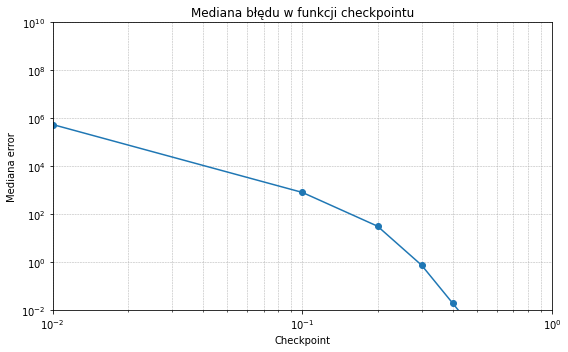

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# === Wczytanie danych ===
# Jeśli masz plik:
# df = pd.read_csv("dane.csv")

# Jeśli wklejasz dane jako string:
from io import StringIO


df = pd.read_csv(
    StringIO(data),
    header=None,
    names=["function", "dimension", "run", "checkpoint", "error"]
)
# df = pd.read_csv("dane.csv")
df.columns = df.columns.str.strip()
print(df.columns)

# === Czyszczenie kolumny error ===
df["error"] = df["error"].str.strip("[]").astype(float)

# === Mediana błędu dla checkpointu ===
median_df = (
    df.groupby("checkpoint", as_index=False)["error"]
    .median()
    .sort_values("checkpoint")
)

# === Wykres ===
plt.figure(figsize=(8, 5))
plt.plot(median_df["checkpoint"], median_df["error"], marker='o')

plt.xscale("log")
plt.yscale("log")

plt.xlim(1e-2, 1e0)
plt.ylim(1e-2, 1e10)

plt.xlabel("Checkpoint")
plt.ylabel("Mediana error")
plt.title("Mediana błędu w funkcji checkpointu")

plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()


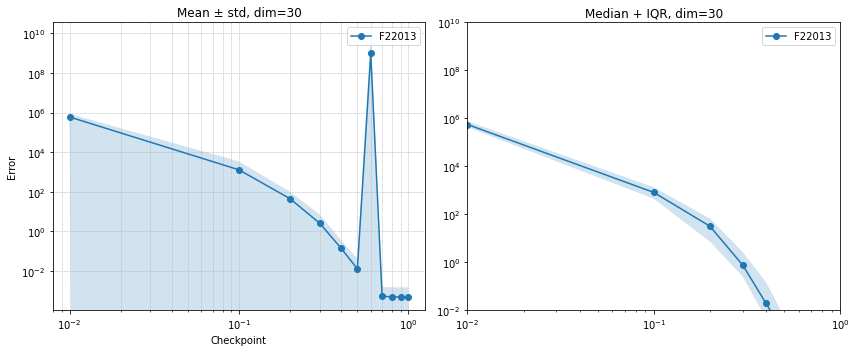

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from io import StringIO

# === Twoje dane ===


# === Wczytanie danych do pandas ===
df = pd.read_csv(StringIO(data), header=None, names=["algorithm","dimensions","unused","checkpoint","error"])
df["error"] = df["error"].str.strip("[]").astype(float)

# === Przygotowanie danych do formatu algs_records ===
algs_records = {}
for alg in df["algorithm"].unique():
    records = []
    for _, row in df[df["algorithm"]==alg].iterrows():
        records.append({
            "dimensions": row["dimensions"],
            "checkpoint": row["checkpoint"],
            "error": row["error"]
        })
    algs_records[alg] = records

# === Lista checkpointów i wymiarów ===
checkpoints = sorted(df["checkpoint"].unique())
def_dimensions = sorted(df["dimensions"].unique())

# === Przygotowanie matplotlib axes ===
fig, axs = plt.subplots(len(def_dimensions), 2, figsize=(12, 5*len(def_dimensions)))

plot_idx = 0
for dim_idx, dim in enumerate(def_dimensions):
    
    # --- Mean ± std ---
    ax = axs[dim_idx, 0] if len(def_dimensions)>1 else axs[0]
    
    for algorithm_name, records in algs_records.items():
        means = []
        stds = []
        for checkpoint in checkpoints:
            vals = [r["error"] for r in records if r["dimensions"]==dim and r["checkpoint"]==checkpoint]
            if vals:
                means.append(np.mean(vals))
                stds.append(np.std(vals))
            else:
                means.append(np.nan)
                stds.append(np.nan)
        
        means = np.array(means)
        stds = np.array(stds)
        ax.plot(checkpoints, means, marker='o', label=algorithm_name)
        ax.fill_between(checkpoints, means-stds, means+stds, alpha=0.2)
    
    ax.set_title(f"Mean ± std, dim={dim}")
    ax.set_xscale("log")
    ax.set_yscale("log")
    plt.xlim(1e-2, 1e0)
    plt.ylim(1e-2, 1e10)
    ax.set_xlabel("Checkpoint")
    ax.set_ylabel("Error")
    ax.grid(True, which="both", linestyle="--", linewidth=0.5)
    ax.legend()
    
    # --- Median + IQR ---
    ax = axs[dim_idx, 1] if len(def_dimensions)>1 else axs[1]
    
    for algorithm_name, records in algs_records.items():
        medians = []
        q25s = []
        q75s = []
        for checkpoint in checkpoints:
            vals = [r["error"] for r in records if r["dimensions"]==dim and r["checkpoint"]==checkpoint]
            if vals:
                medians.append(np.median(vals))
                q25s.append(np.percentile(vals, 25))
                q75s.append(np.percentile(vals, 75))
            else:
                medians.append(np.nan)
                q25s.append(np.nan)
                q75s.append(np.nan)
        
        medians = np.array(medians)
        q25s = np.array(q25s)
        q75s = np.array(q75s)
        ax.plot(checkpoints, medians, marker='o', label=algorithm_name)
        ax.fill_between(checkpoints, q25s, q75s, alpha=0.2)
    
    ax.set_title(f"Median + IQR, dim={dim}")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.legend()

plt.tight_layout()
plt.show()
